In [1]:
import scarf

counts = scarf.cytebase.connect("scarf_docs").download(
    "tenx_5K_pbmc_rnaseq/data.h5",
    destination="scarf_datasets",
)[0]

store = counts.with_name("data.zarr")
reader = scarf.CrH5Reader(str(counts))

Downloading bucket files: 18098007 / 18098007 complete

Downloading bytes: 18098007 / 18098007 complete

In [2]:
reader.nCells, reader.nFeatures

(5025, 33538)

In [3]:
scarf.CrToZarr(reader, zarr_loc=str(store)).dump()

Writing counts: 2 / 2 complete

INFO: execution countsImportBand: read=1/1 compute=1/1 write=1/1 fetch=0.00s compute=0.00s readerWait=0.00s computeWait=0.00s held=0 reason=1 compute workers used because each unit needs 2323253412 bytes; 1 writers used because each unit needs 2323253412 bytes


INFO: Wrote 5025 cells and 33538 features from Cell Ranger to 1 assay(s)


INFO: execution countsRowShard: read=2/2 compute=2/2 write=2/2 fetch=0.00s compute=0.00s readerWait=0.00s computeWait=0.00s held=963011100 reason=full request used


In [4]:
ds = scarf.DataStore(str(store), nthreads=4)

Computing RNA initialization statistics: 1 / 1 complete

INFO: execution initializationRowBand: read=1/1 compute=1/1 write=1/1 fetch=0.52s compute=0.24s readerWait=0.00s computeWait=0.00s held=0 reason=1 compute workers used because there are 1 units


In [5]:
run = ds.pipeline.run(label="baseline")
run

INFO: Running pipeline stage: input snapshot


INFO: Completed pipeline stage: input snapshot


INFO: Running pipeline stage: filtering


INFO: Completed pipeline stage: filtering


INFO: Running pipeline stage: cell cycle


...

Finding markers: 2 / 2 complete

INFO: execution countsTReadGroup: read=2/2 compute=2/2 write=1/1 fetch=27.51s compute=0.69s readerWait=16.08s computeWait=0.00s held=1293608976 reason=2 readers used because there are 2 units; 2 compute workers used because there are 2 units


INFO: Stored marker results for 11 clusters


INFO: Completed pipeline stage: markers


PipelineRun(run_id='31e3658afee2...', status='completed', assay='RNA', label='baseline')

In [6]:
run.cells.to_pandas_dataframe(["clusters"])["clusters"].value_counts().sort_index()

clusters
1      893
2      271
3     1447
4      356
5      506
6      240
7      273
8      503
9       31
10      75
11      23
Name: count, dtype: int64

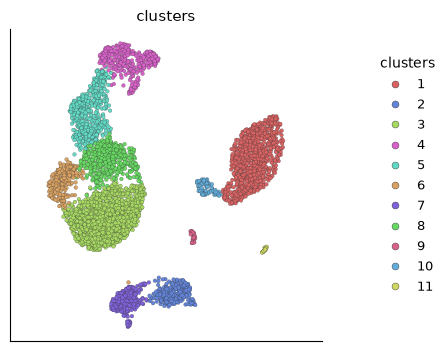

In [7]:
ds.plots.embedding(run=run, layout="umap", color_by="clusters")

In [8]:
cluster_id = run.cells.fetch("clusters")[0]
ds.get_markers(marker=run["markers"], group_id=cluster_id).head(10)

,group_id,feature_name,feature_index,score,mean,mean_rest,frac_exp,frac_exp_rest,fold_change,p_value,auc,p_value_adjusted
0,1,ALDH1A1,16188,0.90473,0.11013,0.00021,0.49496,0.00188,520.16052,0.000000e+00,0.74677,0.000000e+00
1,1,VCAN,9167,0.90104,1.42918,0.00539,0.98096,0.03517,265.05269,0.000000e+00,0.98940,0.000000e+00
2,1,CD163,20272,0.89664,0.08396,0.00026,0.52296,0.00161,322.01773,0.000000e+00,0.76064,0.000000e+00
3,1,S100A12,1925,0.89474,1.19033,0.00246,0.94065,0.01423,484.17284,0.000000e+00,0.96875,0.000000e+00
4,1,QPCT,3559,0.88969,0.07802,0.00024,0.46473,0.00215,326.23693,0.000000e+00,0.73145,0.000000e+00
5,1,CLEC4E,20297,0.88841,0.10725,0.00044,0.56999,0.00242,246.42651,0.000000e+00,0.78402,0.000000e+00
6,1,CD14,9635,0.88828,0.86574,0.00331,0.96417,0.02121,261.83544,0.000000e+00,0.98075,0.000000e+00
7,1,CYP27A1,5135,0.82495,0.08786,0.00042,0.45129,0.00349,210.79798,0.000000e+00,0.72417,0.000000e+00
8,1,ASGR2,26811,0.82383,0.06663,0.00028,0.41209,0.00295,236.61005,0.000000e+00,0.70479,0.000000e+00
9,1,FOLR3,18203,0.82245,0.04833,0.00010,0.33819,0.00081,497.46602,1.427520e-290,0.66871,1.549391e-288


In [9]:
assert ds.pipeline.open(label="baseline").run_id == run.run_id